Iris Dataset Overview:
Dataset shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Correlation Matrix:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)               1.00             -0.12               0.87   
sepal width (cm)               -0.12              1.00              -0.43   
petal length (cm)               0.87             -0.43 

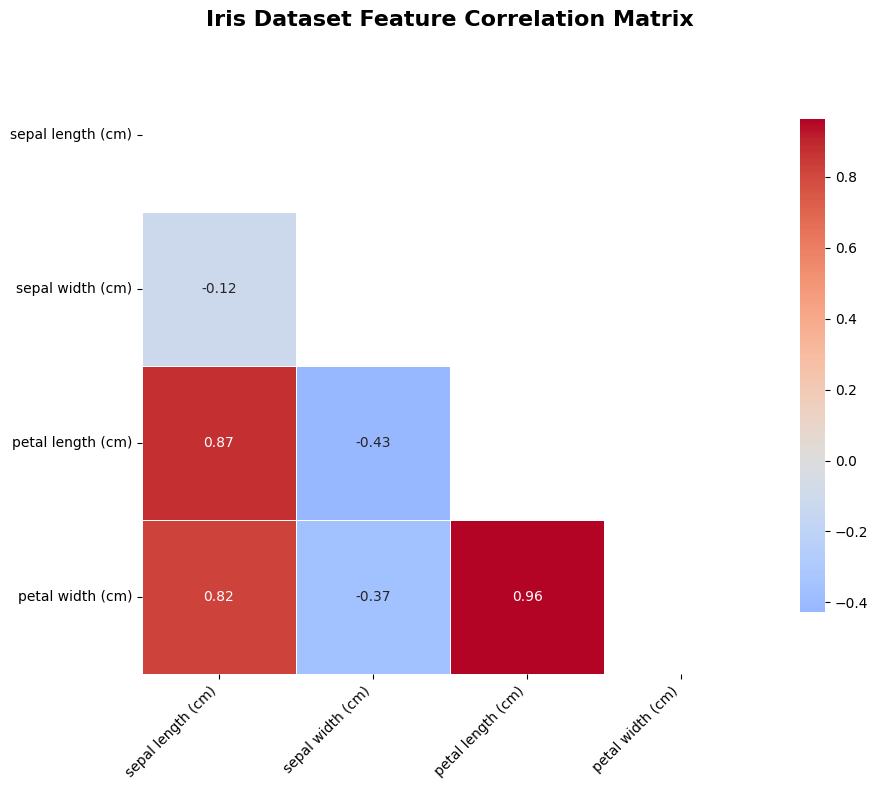


Strong Correlations Analysis:
Strong correlations (|r| > 0.7):
sepal length (cm) - petal length (cm): 0.872
sepal length (cm) - petal width (cm): 0.818
petal length (cm) - petal width (cm): 0.963


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target

# Map target values to species names
species_names = {
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
}

df['species_name'] = df['species'].map(species_names)

# Display dataset overview
print("Iris Dataset Overview:")
print(f"Dataset shape: {df.shape}")

print("\nFirst 5 rows:")
print(df.head())

# Compute correlation matrix for numerical features
numeric_df = df.select_dtypes(
    include=[np.number]
).drop('species', axis=1)

corr_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix.round(2))

# Plot heatmap
plt.figure(figsize=(10, 8))

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)

heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    fmt='.2f',
    cbar_kws={'shrink': 0.8},
    linewidths=0.5
)

plt.title(
    'Iris Dataset Feature Correlation Matrix\n',
    fontsize=16,
    fontweight='bold'
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Strong correlations analysis
print("\nStrong Correlations Analysis:")

strong_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > 0.7:
            strong_corr.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_value
                )
            )

print("Strong correlations (|r| > 0.7):")

for feature1, feature2, corr_value in strong_corr:
    print(
        f"{feature1} - {feature2}: {corr_value:.3f}"
    )